Selected Features: Index(['Feature1', 'Feature3', 'Feature1_Augmented'], dtype='object')


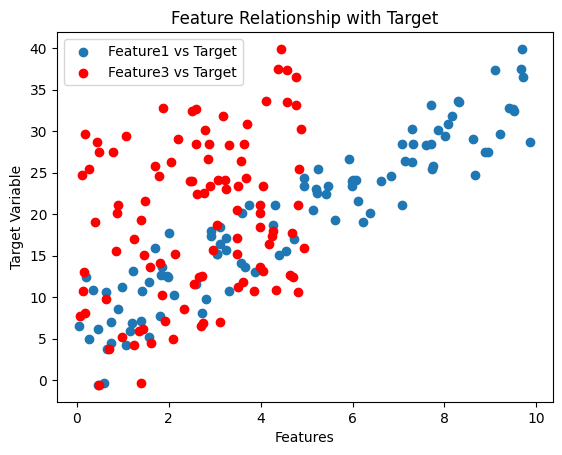

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

# Generate synthetic data
np.random.seed(42)
X1 = np.random.rand(100) * 10  # Feature 1: Random numbers
X2 = X1 + np.random.randn(100) * 0.5  # Feature 2: Correlated with X1
X3 = np.random.rand(100) * 5  # Feature 3: Random numbers
y = 3 * X1 + 2 * X3 + np.random.randn(100) * 1.5  # Target with noise

# Convert to DataFrame
data = pd.DataFrame({'Feature1': X1, 'Feature2': X2, 'Feature3': X3, 'Target': y})

# -------- DATA AUGMENTATION --------
# Adding synthetic noise to X1
data['Feature1_Augmented'] = data['Feature1'] + np.random.randn(100) * 0.2

# -------- FEATURE ENGINEERING --------
# Creating a new interaction feature
data['Feature_Interaction'] = data['Feature1'] * data['Feature3']

# -------- FEATURE SELECTION --------
X = data.drop(columns=['Target'])  # Select all features except target
y = data['Target']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use Recursive Feature Elimination (RFE) for feature selection
model = LinearRegression()
selector = RFE(model, n_features_to_select=3)  # Select top 3 features
selector.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[selector.support_]
print("Selected Features:", selected_features)

# -------- PLOTTING --------
plt.scatter(data['Feature1'], data['Target'], label='Feature1 vs Target')
plt.scatter(data['Feature3'], data['Target'], label='Feature3 vs Target', color='red')
plt.xlabel("Features")
plt.ylabel("Target Variable")
plt.legend()
plt.title("Feature Relationship with Target")
plt.show()

